# 🍚 Rice Variety Classification
## TensorFlow/Keras vs PyTorch

This project develops a lightweight Convolutional Neural Network (CNN) for
classifying five different rice varieties from images.

The same classification task is implemented using two major deep learning
frameworks:

- TensorFlow / Keras
- PyTorch

### Rice Varieties

The dataset contains five rice varieties:

- Arborio
- Basmati
- Ipsala
- Jasmine
- Karacadag

## Project Overview

This notebook follows a complete image classification workflow, starting
from raw dataset acquisition and inspection and ending with model evaluation
and framework comparison.

The experiment is intentionally based on a relatively small CNN architecture.
The goal is to obtain a strong and efficient baseline without relying on
large pretrained architectures or transfer learning.

To make the comparison meaningful, the two implementations will use the same:

- Dataset
- Train/validation/test split
- Input image size
- Number of classes
- CNN architecture
- Batch size
- Number of training epochs
- Optimizer
- Learning rate
- Evaluation protocol

This allows us to focus the comparison on the two framework implementations
rather than differences in experimental setup.

## 1. Environment Setup

This notebook is designed to run in **Google Colab**.

The environment setup below installs only the additional packages required for
the project. Most commonly used scientific Python libraries are already
available in Google Colab.

To improve reproducibility, the main package versions used during the
experiment are displayed after installation.

In [1]:
%pip install -q kagglehub seaborn scikit-learn

## 2. Experiment Configuration

All major experiment parameters are centralized in a single configuration
object.

Keeping configuration values in one place makes the experiment easier to
reproduce, modify, and maintain.

In [22]:
from dataclasses import dataclass


@dataclass
class Config:
    # Reproducibility
    seed: int = 42

    # Image configuration
    image_size: tuple = (128, 128)
    num_channels: int = 3

    # Dataset split
    train_ratio: float = 0.60
    val_ratio: float = 0.20
    test_ratio: float = 0.20

    # Training
    batch_size: int = 64
    epochs: int = 15
    learning_rate: float = 1e-3

    # Training control
    early_stopping_patience: int = 4
    lr_patience: int = 2
    lr_factor: float = 0.5

    # DataLoader
    num_workers: int = 2


CFG = Config()

print(CFG)

Config(seed=42, image_size=(128, 128), num_channels=3, train_ratio=0.6, val_ratio=0.2, test_ratio=0.2, batch_size=64, epochs=15, learning_rate=0.001, early_stopping_patience=4, lr_patience=2, lr_factor=0.5, num_workers=2)


## 3. Imports

The following libraries are used throughout the project for:

- Dataset handling
- Numerical computation
- Visualization
- Model training
- Evaluation
- Reproducibility

In [3]:
import os
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import kagglehub

## 4. Reproducibility

Machine learning experiments can produce slightly different results when
random operations are not controlled.

To make the experiment as reproducible as possible, we fix the random seed
for Python, NumPy, TensorFlow, and PyTorch.

Exact reproducibility can still depend on the hardware and backend
configuration, but controlling the main random sources provides a consistent
experimental setup.

In [4]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)

    tf.random.set_seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)

    # Request deterministic behavior where possible
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(CFG.seed)

print(f"Random seed set to: {CFG.seed}")

Random seed set to: 42


## 5. Computing

Before starting the experiment, we check whether a GPU is available.

The notebook is designed to run on Google Colab and can operate on either
CPU or GPU, although GPU acceleration is recommended for training.

In [5]:
print("TensorFlow GPU devices:")
print(tf.config.list_physical_devices("GPU"))

print("\nPyTorch device:")

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

TensorFlow GPU devices:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

PyTorch device:
cuda
GPU: Tesla T4


## 6. Dataset

The project uses the Rice Image Dataset published by Murat Koklu.

The dataset contains 75,000 rice grain images distributed across five
varieties, with 15,000 images per class.

The dataset is downloaded programmatically using `kagglehub`. This avoids
storing the dataset itself inside the Git repository and makes the notebook
easier to reproduce.

Dataset source:

Murat Koklu, Cinar, and Taspinar, "Classification of rice varieties with
deep learning methods", Computers and Electronics in Agriculture, 2021.

In [6]:
print("Downloading Rice Image Dataset...")

dataset_path = kagglehub.dataset_download(
    "muratkokludataset/rice-image-dataset"
)

dataset_path = Path(dataset_path)

print(f"\nDataset downloaded to:")
print(dataset_path)

Using Colab cache for faster access to the 'rice-image-dataset' dataset.

Dataset downloaded to:
/kaggle/input/rice-image-dataset


### Dataset Directory Structure

The downloaded archive may contain an additional parent directory depending
on how KaggleHub stores the dataset.

We therefore locate the directory containing the five expected class
folders instead of hard-coding a single path.

In [7]:
EXPECTED_CLASSES = {
    "Arborio",
    "Basmati",
    "Ipsala",
    "Jasmine",
    "Karacadag"
}


def find_image_directory(root: Path) -> Path:
    for current_root, dirs, files in os.walk(root):
        current_dirs = set(dirs)

        if EXPECTED_CLASSES.issubset(current_dirs):
            return Path(current_root)

    raise FileNotFoundError(
        "Could not locate the Rice Image Dataset directory."
    )


image_dir = find_image_directory(dataset_path)

classes = sorted(
    [
        d.name
        for d in image_dir.iterdir()
        if d.is_dir()
    ]
)

print(f"Image directory: {image_dir}")
print(f"Classes: {classes}")

Image directory: /kaggle/input/rice-image-dataset/Rice_Image_Dataset
Classes: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']


## 7. Dataset Inspection

Before training a neural network, we first inspect the dataset.

This step is important for detecting issues such as:

- Missing classes
- Unexpected directory structures
- Imbalanced class distributions
- Unsupported image files
- Incorrect image dimensions
- Unexpected color formats

The dataset is expected to contain five balanced classes.

In [8]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}


def collect_image_paths(root: Path):
    records = []

    for class_name in classes:
        class_dir = root / class_name

        for image_path in class_dir.iterdir():
            if image_path.suffix.lower() in IMAGE_EXTENSIONS:
                records.append(
                    {
                        "filepath": str(image_path),
                        "class_name": class_name
                    }
                )

    return pd.DataFrame(records)


df = collect_image_paths(image_dir)

print(f"Total images: {len(df):,}")
print("\nImages per class:")
print(df["class_name"].value_counts().sort_index())

Total images: 75,000

Images per class:
class_name
Arborio      15000
Basmati      15000
Ipsala       15000
Jasmine      15000
Karacadag    15000
Name: count, dtype: int64


## 8. Visualizing the Dataset

Before building the CNN, we visually inspect representative images from
each rice variety.

This provides a simple sanity check that:

1. The correct images were loaded.
2. The class labels match the directory structure.
3. The images are readable and visually consistent.
4. The five classes have comparable visual characteristics.

The images are displayed in their original RGB representation.

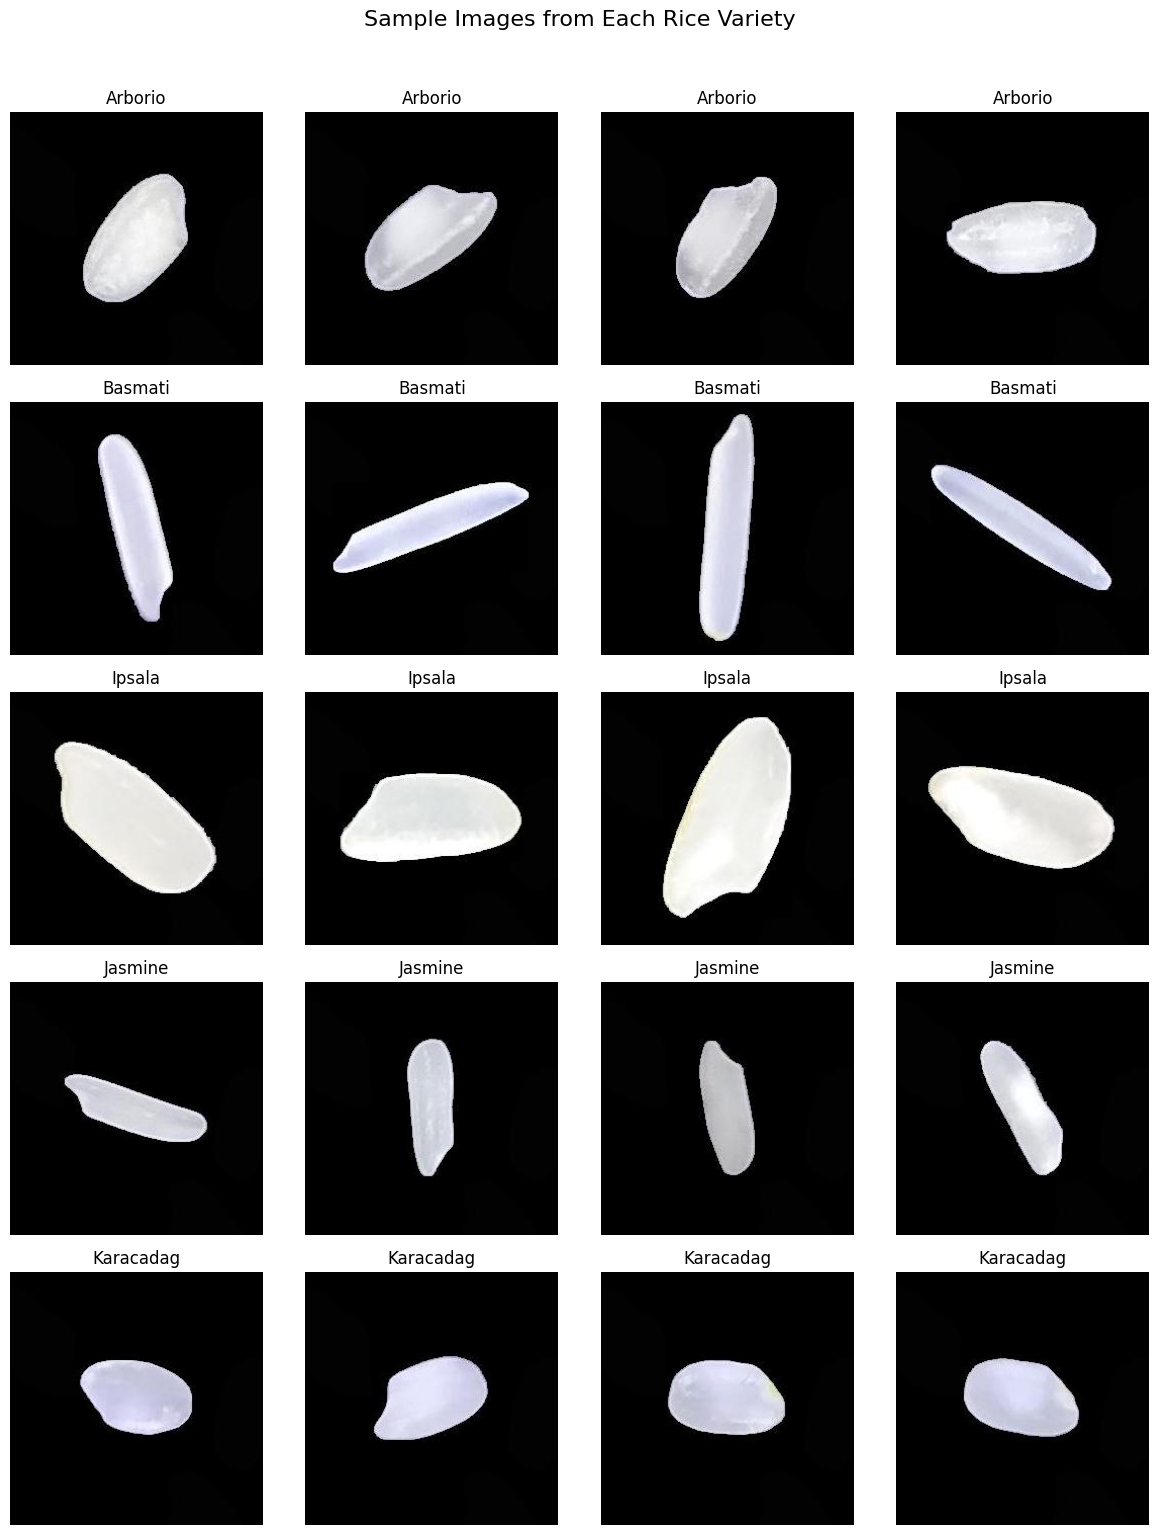

In [9]:
fig, axes = plt.subplots(
    nrows=len(classes),
    ncols=4,
    figsize=(12, 3 * len(classes))
)

for row, class_name in enumerate(classes):

    class_images = df[
        df["class_name"] == class_name
    ]["filepath"].tolist()

    selected_images = random.sample(
        class_images,
        min(4, len(class_images))
    )

    for col, image_path in enumerate(selected_images):

        image = Image.open(image_path).convert("RGB")

        axes[row, col].imshow(image)
        axes[row, col].set_title(class_name)
        axes[row, col].axis("off")

plt.suptitle(
    "Sample Images from Each Rice Variety",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

### Image Properties

We also inspect the dimensions and color representation of a sample image.

Although the images visually contain a predominantly dark background and
light rice grains, they are stored as RGB images. We therefore preserve the
three color channels throughout this experiment.

In [10]:
sample_path = df.iloc[0]["filepath"]

with Image.open(sample_path) as sample_image:
    print(f"Image path: {sample_path}")
    print(f"Image size: {sample_image.size}")
    print(f"Image mode: {sample_image.mode}")

Image path: /kaggle/input/rice-image-dataset/Rice_Image_Dataset/Arborio/Arborio (5529).jpg
Image size: (250, 250)
Image mode: RGB


### Class Distribution

A balanced dataset is useful for multiclass classification because it reduces
the risk of the model being biased toward a particular class.

We visualize the number of samples in each class before creating the
train/validation/test split.

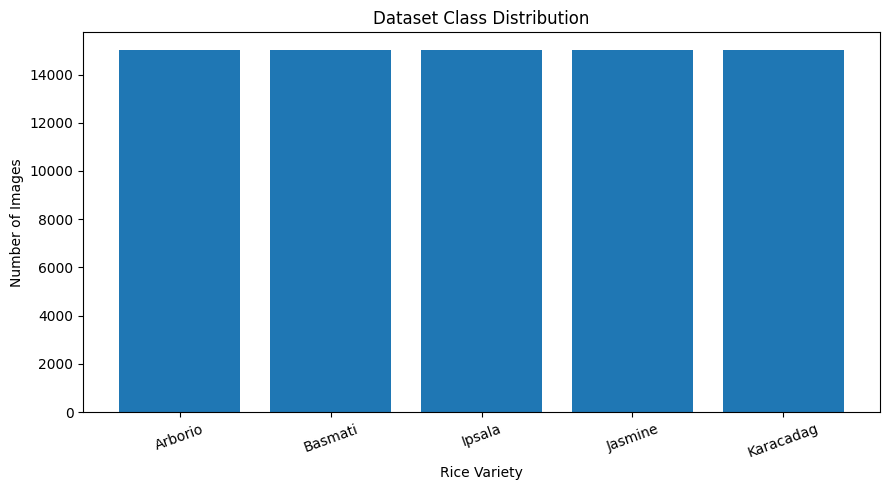

In [11]:
class_counts = (
    df["class_name"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(9, 5))

plt.bar(
    class_counts.index,
    class_counts.values
)

plt.title("Dataset Class Distribution")
plt.xlabel("Rice Variety")
plt.ylabel("Number of Images")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

## 9. Train / Validation / Test Split

The dataset is divided into three subsets:

- 60% training
- 20% validation
- 20% testing

The split is performed at the file-path level rather than physically copying
images into separate directories.

This approach avoids unnecessary duplication of the dataset and keeps the
pipeline lightweight.

Stratified splitting is used to preserve the class distribution across all
three subsets.

In [12]:
train_df, temp_df = train_test_split(
    df,
    test_size=(CFG.val_ratio + CFG.test_ratio),
    stratify=df["class_name"],
    random_state=CFG.seed
)

relative_test_ratio = (
    CFG.test_ratio /
    (CFG.val_ratio + CFG.test_ratio)
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=relative_test_ratio,
    stratify=temp_df["class_name"],
    random_state=CFG.seed
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train:      {len(train_df):,}")
print(f"Validation: {len(val_df):,}")
print(f"Test:       {len(test_df):,}")

Train:      45,000
Validation: 15,000
Test:       15,000


In [13]:
split_summary = pd.DataFrame({
    "Train": train_df["class_name"].value_counts(),
    "Validation": val_df["class_name"].value_counts(),
    "Test": test_df["class_name"].value_counts()
}).sort_index()

print(split_summary)

            Train  Validation  Test
class_name                         
Arborio      9000        3000  3000
Basmati      9000        3000  3000
Ipsala       9000        3000  3000
Jasmine      9000        3000  3000
Karacadag    9000        3000  3000


## 10. Label Encoding

Neural networks operate on numerical labels rather than string class names.

We therefore create one shared class-to-index mapping and use it for both
TensorFlow/Keras and PyTorch.

Using the same mapping is important for a fair comparison between the two
frameworks.

In [14]:
class_to_idx = {
    class_name: idx
    for idx, class_name in enumerate(classes)
}

idx_to_class = {
    idx: class_name
    for class_name, idx in class_to_idx.items()
}

print("Class mapping:")
for class_name, idx in class_to_idx.items():
    print(f"{idx}: {class_name}")

Class mapping:
0: Arborio
1: Basmati
2: Ipsala
3: Jasmine
4: Karacadag


## 11. TensorFlow / Keras Data Pipeline

For Keras, we create a dataset directly from the image file paths.

Training images receive lightweight augmentation, while validation and test
images only undergo resizing and normalization.

The test set is never augmented because evaluation should represent the
model's performance on the original data distribution.

In [15]:
from tensorflow.keras import layers


def load_and_preprocess_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(
        image,
        CFG.image_size
    )

    image = tf.cast(image, tf.float32) / 255.0

    return image, label


def build_tf_dataset(dataframe, training=False):

    paths = dataframe["filepath"].values

    labels = np.array([
        class_to_idx[x]
        for x in dataframe["class_name"]
    ])

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=CFG.seed,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_and_preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(CFG.batch_size)

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset


train_tf = build_tf_dataset(
    train_df,
    training=True
)

val_tf = build_tf_dataset(
    val_df,
    training=False
)

test_tf = build_tf_dataset(
    test_df,
    training=False
)

print("TensorFlow datasets created.")

TensorFlow datasets created.


### Training Augmentation

The training pipeline uses mild geometric augmentation to improve
generalization.

Augmentation is applied only to training images. Validation and test images
remain unchanged apart from resizing and normalization.

In [16]:
keras_augmentation = tf.keras.Sequential([
    layers.RandomFlip(
        mode="horizontal",
        seed=CFG.seed
    ),

    layers.RandomRotation(
        factor=8 / 360,
        seed=CFG.seed
    ),
], name="augmentation")

## 12. CNN Architecture

To ensure a fair comparison between TensorFlow/Keras and PyTorch, both
implementations use the same CNN architecture and approximately the same
training configuration.

The architecture is intentionally compact to keep training efficient in
Google Colab while providing a strong baseline for rice variety
classification.

### Shared Architecture

```text
Input: 128 × 128 × 3

Conv2D: 32 filters, 3×3, same padding
ReLU
MaxPool: 2×2

Conv2D: 64 filters, 3×3, same padding
ReLU
MaxPool: 2×2

Conv2D: 128 filters, 3×3, same padding
ReLU
MaxPool: 2×2

Global Average Pooling

Dense: 128
ReLU
Dropout: 0.4

Output: 5 classes

In [23]:
def build_keras_model(num_classes):

    inputs = tf.keras.Input(
        shape=(
            CFG.image_size[0],
            CFG.image_size[1],
            CFG.num_channels
        )
    )

    # Data augmentation
    x = keras_augmentation(inputs)

    x = layers.Conv2D(
        filters=32,
        kernel_size=3,
        padding="same",
        activation="relu"
    )(x)

    x = layers.MaxPooling2D(
        pool_size=2
    )(x)

    x = layers.Conv2D(
        filters=64,
        kernel_size=3,
        padding="same",
        activation="relu"
    )(x)

    x = layers.MaxPooling2D(
        pool_size=2
    )(x)

    x = layers.Conv2D(
        filters=128,
        kernel_size=3,
        padding="same",
        activation="relu"
    )(x)

    x = layers.MaxPooling2D(
        pool_size=2
    )(x)

    # Classification head
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(
        128,
        activation="relu"
    )(x)

    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(
        num_classes,
        activation="softmax"
    )(x)

    return tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="RiceCNN_Keras"
    )

In [24]:
keras_model = build_keras_model(
    num_classes=len(classes)
)

keras_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=CFG.learning_rate
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

keras_model.summary()

Model: "RiceCNN_Keras"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,405 (431.27 KB)

 Trainable params: 110,405 (431.27 KB)

 Non-trainable params: 0 (0.00 B)

## 13. Training — TensorFlow / Keras

The Keras model is trained using Adam optimization.

Two training controls are used:

- Early stopping: prevents unnecessary training once validation performance
  stops improving.
- Learning-rate reduction: lowers the learning rate when validation loss
  plateaus.

The best model is restored after training.

In [25]:
callbacks_keras = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath="best_keras_model.keras",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    )
]

keras_start_time = time.perf_counter()

history_keras = keras_model.fit(
    train_tf,
    validation_data=val_tf,
    epochs=CFG.epochs,
    callbacks=callbacks_keras,
    verbose=1
)

keras_training_time = time.perf_counter() - keras_start_time

print(
    f"\nKeras training time: "
    f"{keras_training_time:.2f} seconds"
)

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.5122 - loss: 1.0510
Epoch 1: val_accuracy improved from None to 0.83247, saving model to best_keras_model.keras

Epoch 1: finished saving model to best_keras_model.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 120s 160ms/step - accuracy: 0.6874 - loss: 0.7176 - val_accuracy: 0.8325 - val_loss: 0.3832 - learning_rate: 0.0010
Epoch 2/15
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9071 - loss: 0.2684
Epoch 2: val_accuracy improved from 0.83247 to 0.83413, saving model to best_keras_model.keras

Epoch 2: finished saving model to best_keras_model.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 55ms/step - accuracy: 0.9152 - loss: 0.2430 - val_accuracy: 0.8341 - val_loss: 0.3869 - learning_rate: 0.0010
Epoch 3/15
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9378 - loss: 0.1757
Epoch 3: val_accuracy improved from 0.83413 to 0.92707, saving model to best_keras_model.keras

Epoch 3: finished saving model to best_keras_model.

In [26]:
keras_test_loss, keras_test_accuracy = keras_model.evaluate(
    test_tf,
    verbose=0
)

print(f"Keras Test Loss:     {keras_test_loss:.4f}")
print(f"Keras Test Accuracy: {keras_test_accuracy:.4f}")

Keras Test Loss:     0.0844
Keras Test Accuracy: 0.9725


## 14. PyTorch Data Pipeline

The same image files and class mapping are used to create the PyTorch
datasets.

The preprocessing strategy follows the same overall protocol as the Keras
pipeline:

- Resize to 128 × 128
- Convert to RGB
- Pixel values are scaled to the [0, 1] range
- Apply lightweight training augmentation only to the training set

The validation and test sets remain free of augmentation.

In [27]:
class RiceDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_size,
        training=False
    ):

        self.dataframe = dataframe.reset_index(drop=True)

        if training:
            self.transform = transforms.Compose([
                transforms.Resize(image_size),
                transforms.RandomHorizontalFlip(),
                transforms.RandomRotation(8),
                transforms.ToTensor()
            ])

        else:
            self.transform = transforms.Compose([
                transforms.Resize(image_size),
                transforms.ToTensor()
            ])

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image = Image.open(
            row["filepath"]
        ).convert("RGB")

        label = class_to_idx[
            row["class_name"]
        ]

        image = self.transform(image)

        return image, label

In [28]:
train_dataset = RiceDataset(
    train_df,
    CFG.image_size,
    training=True
)

val_dataset = RiceDataset(
    val_df,
    CFG.image_size,
    training=False
)

test_dataset = RiceDataset(
    test_df,
    CFG.image_size,
    training=False
)


train_loader = DataLoader(
    train_dataset,
    batch_size=CFG.batch_size,
    shuffle=True,
    num_workers=CFG.num_workers,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CFG.batch_size,
    shuffle=False,
    num_workers=CFG.num_workers,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CFG.batch_size,
    shuffle=False,
    num_workers=CFG.num_workers,
    pin_memory=torch.cuda.is_available()
)

print(f"Train samples: {len(train_dataset):,}")
print(f"Val samples:   {len(val_dataset):,}")
print(f"Test samples:  {len(test_dataset):,}")

Train samples: 45,000
Val samples:   15,000
Test samples:  15,000


### DataLoader Sanity Check

Before training, we inspect one batch from the PyTorch DataLoader.

This confirms that:

- **Images have the expected tensor shape.**
- **Labels are numerical.**
- **The batch size is correct.**
- **Images are correctly normalized.**

In [29]:
images, labels = next(iter(train_loader))

print(f"Image batch shape: {images.shape}")
print(f"Label batch shape: {labels.shape}")
print(
    f"Pixel range: "
    f"{images.min().item():.3f} - "
    f"{images.max().item():.3f}"
)

Image batch shape: torch.Size([64, 3, 128, 128])
Label batch shape: torch.Size([64])
Pixel range: 0.000 - 1.000


In [30]:
class RiceCNN(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        # Feature extractor
        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Global Average Pooling
        self.global_pool = nn.AdaptiveAvgPool2d(
            output_size=(1, 1)
        )

        # Classification head
        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                in_features=128,
                out_features=128
            ),

            nn.ReLU(),

            nn.Dropout(0.4),

            nn.Linear(
                in_features=128,
                out_features=num_classes
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = self.global_pool(x)

        x = self.classifier(x)

        return x

In [31]:
torch_model = RiceCNN(
    num_classes=len(classes)
).to(device)

print(torch_model)

RiceCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (global_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=5, bias=True)
  )
)


## 15. PyTorch Training Loop

Unlike Keras, PyTorch requires the training loop to be explicitly defined.

The training function below handles:

- Forward propagation
- Loss calculation
- Backpropagation
- Optimizer updates
- Training metrics
- Validation metrics
- Learning-rate scheduling
- Early stopping
- Best-model checkpointing

The function is kept independent of global training variables so that it can
be reused with other models or experiments.

In [32]:
def run_epoch(
    model,
    loader,
    criterion,
    optimizer=None
):

    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    context = torch.enable_grad() if is_training else torch.no_grad()

    with context:

        for images, labels in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            if is_training:
                optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            if is_training:

                loss.backward()

                optimizer.step()

            running_loss += (
                loss.item() *
                images.size(0)
            )

            predictions = outputs.argmax(
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [33]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    torch_model.parameters(),
    lr=CFG.learning_rate
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=CFG.lr_factor,
    patience=CFG.lr_patience,
    min_lr=1e-6
)


torch_history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}


best_val_loss = float("inf")
patience_counter = 0

best_model_path = "best_pytorch_model.pth"


torch_start_time = time.perf_counter()


for epoch in range(CFG.epochs):

    train_loss, train_acc = run_epoch(
        torch_model,
        train_loader,
        criterion,
        optimizer
    )

    val_loss, val_acc = run_epoch(
        torch_model,
        val_loader,
        criterion
    )

    torch_history["train_loss"].append(
        train_loss
    )

    torch_history["train_accuracy"].append(
        train_acc
    )

    torch_history["val_loss"].append(
        val_loss
    )

    torch_history["val_accuracy"].append(
        val_acc
    )

    scheduler.step(val_loss)

    print(
        f"Epoch {epoch + 1:02d}/{CFG.epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            torch_model.state_dict(),
            best_model_path
        )

        patience_counter = 0

    else:

        patience_counter += 1

        if patience_counter >= CFG.early_stopping_patience:

            print("Early stopping triggered.")

            break


torch_training_time = (
    time.perf_counter() -
    torch_start_time
)

print(
    f"\nPyTorch training time: "
    f"{torch_training_time:.2f} seconds"
)

Epoch 01/15 | Train Loss: 0.8730 | Train Acc: 0.5986 | Val Loss: 0.5883 | Val Acc: 0.7181
Epoch 02/15 | Train Loss: 0.3830 | Train Acc: 0.8588 | Val Loss: 0.3368 | Val Acc: 0.8681
Epoch 03/15 | Train Loss: 0.2608 | Train Acc: 0.9047 | Val Loss: 0.2276 | Val Acc: 0.9187
Epoch 04/15 | Train Loss: 0.2354 | Train Acc: 0.9149 | Val Loss: 0.1610 | Val Acc: 0.9383
Epoch 05/15 | Train Loss: 0.2011 | Train Acc: 0.9282 | Val Loss: 0.2344 | Val Acc: 0.9133
Epoch 06/15 | Train Loss: 0.2007 | Train Acc: 0.9287 | Val Loss: 0.1373 | Val Acc: 0.9521
Epoch 07/15 | Train Loss: 0.1665 | Train Acc: 0.9418 | Val Loss: 0.1043 | Val Acc: 0.9633
Epoch 08/15 | Train Loss: 0.1468 | Train Acc: 0.9492 | Val Loss: 0.1007 | Val Acc: 0.9632
Epoch 09/15 | Train Loss: 0.1388 | Train Acc: 0.9522 | Val Loss: 0.1487 | Val Acc: 0.9458
Epoch 10/15 | Train Loss: 0.1172 | Train Acc: 0.9598 | Val Loss: 0.0598 | Val Acc: 0.9788
Epoch 11/15 | Train Loss: 0.1010 | Train Acc: 0.9655 | Val Loss: 0.0917 | Val Acc: 0.9660
Epoch 12/1

In [37]:
torch_model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device
    )
)

torch_model.eval()

print("Best PyTorch model loaded.")

Best PyTorch model loaded.


## 16. Model Evaluation

The final evaluation is performed on the held-out test set.

The test set has not been used for:

- Training
- Hyperparameter tuning
- Early stopping
- Model selection

This helps provide an unbiased estimate of the final model performance.

In [38]:
torch_test_loss, torch_test_accuracy = run_epoch(
    torch_model,
    test_loader,
    criterion
)

print(f"PyTorch Test Loss:     {torch_test_loss:.4f}")
print(f"PyTorch Test Accuracy: {torch_test_accuracy:.4f}")

PyTorch Test Loss:     0.0513
PyTorch Test Accuracy: 0.9817


## 17. Training Curves

Training and validation curves help us understand how each model learned
during training.

We compare both frameworks using:

- Training accuracy
- Validation accuracy
- Training loss
- Validation loss

These curves can reveal underfitting, overfitting, or unstable training.

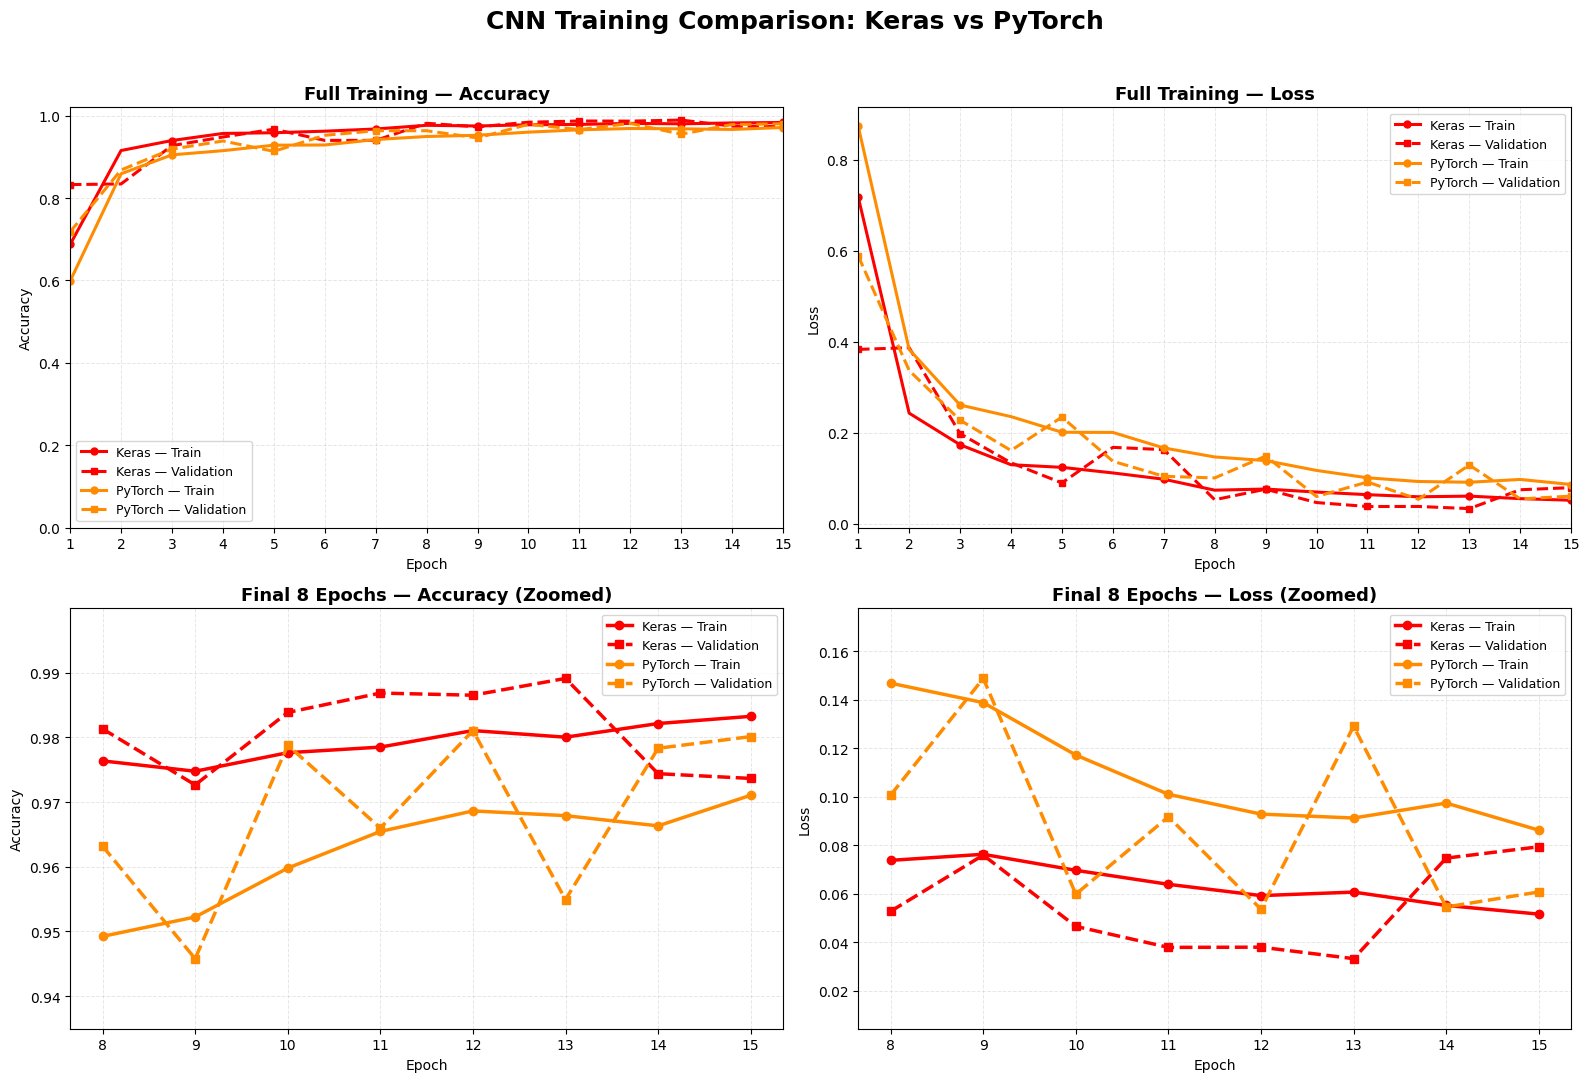

In [45]:
KERAS_COLOR = "red"
PYTORCH_COLOR = "darkorange"
ZOOM_LAST_EPOCHS = 8


keras_epochs = np.arange(
    1,
    len(history_keras.history["accuracy"]) + 1
)

torch_epochs = np.arange(
    1,
    len(torch_history["train_accuracy"]) + 1
)

max_epoch = max(
    len(keras_epochs),
    len(torch_epochs)
)

# Markers every 2 epochs
keras_marker_idx = np.arange(
    0,
    len(keras_epochs),
    2
)

torch_marker_idx = np.arange(
    0,
    len(torch_epochs),
    2
)


# ZOOM INDICES

zoom_start = max(
    1,
    max_epoch - ZOOM_LAST_EPOCHS + 1
)

zoom_epochs = np.arange(
    zoom_start,
    max_epoch + 1
)

keras_zoom_idx = np.arange(
    zoom_start - 1,
    len(keras_epochs)
)

torch_zoom_idx = np.arange(
    zoom_start - 1,
    len(torch_epochs)
)


# CREATE FIGURE

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 11)
)

fig.suptitle(
    "CNN Training Comparison: Keras vs PyTorch",
    fontsize=18,
    fontweight="bold"
)


# 1. FULL TRAINING — ACCURACY

ax = axes[0, 0]

ax.plot(
    keras_epochs,
    history_keras.history["accuracy"],
    color=KERAS_COLOR,
    linestyle="-",
    linewidth=2.2,
    marker="o",
    markersize=5,
    markevery=keras_marker_idx,
    label="Keras — Train"
)

ax.plot(
    keras_epochs,
    history_keras.history["val_accuracy"],
    color=KERAS_COLOR,
    linestyle="--",
    linewidth=2.2,
    marker="s",
    markersize=5,
    markevery=keras_marker_idx,
    label="Keras — Validation"
)

ax.plot(
    torch_epochs,
    torch_history["train_accuracy"],
    color=PYTORCH_COLOR,
    linestyle="-",
    linewidth=2.2,
    marker="o",
    markersize=5,
    markevery=torch_marker_idx,
    label="PyTorch — Train"
)

ax.plot(
    torch_epochs,
    torch_history["val_accuracy"],
    color=PYTORCH_COLOR,
    linestyle="--",
    linewidth=2.2,
    marker="s",
    markersize=5,
    markevery=torch_marker_idx,
    label="PyTorch — Validation"
)

ax.set_title(
    "Full Training — Accuracy",
    fontsize=13,
    fontweight="bold"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")

ax.set_xlim(1, max_epoch)
ax.set_ylim(0, 1.02)

ax.set_xticks(
    np.arange(1, max_epoch + 1)
)

ax.grid(
    True,
    linestyle="--",
    linewidth=0.7,
    alpha=0.3
)

ax.legend(
    fontsize=9,
    frameon=True
)


# 2. FULL TRAINING — LOSS

ax = axes[0, 1]

ax.plot(
    keras_epochs,
    history_keras.history["loss"],
    color=KERAS_COLOR,
    linestyle="-",
    linewidth=2.2,
    marker="o",
    markersize=5,
    markevery=keras_marker_idx,
    label="Keras — Train"
)

ax.plot(
    keras_epochs,
    history_keras.history["val_loss"],
    color=KERAS_COLOR,
    linestyle="--",
    linewidth=2.2,
    marker="s",
    markersize=5,
    markevery=keras_marker_idx,
    label="Keras — Validation"
)

ax.plot(
    torch_epochs,
    torch_history["train_loss"],
    color=PYTORCH_COLOR,
    linestyle="-",
    linewidth=2.2,
    marker="o",
    markersize=5,
    markevery=torch_marker_idx,
    label="PyTorch — Train"
)

ax.plot(
    torch_epochs,
    torch_history["val_loss"],
    color=PYTORCH_COLOR,
    linestyle="--",
    linewidth=2.2,
    marker="s",
    markersize=5,
    markevery=torch_marker_idx,
    label="PyTorch — Validation"
)

ax.set_title(
    "Full Training — Loss",
    fontsize=13,
    fontweight="bold"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")

ax.set_xlim(1, max_epoch)

ax.set_xticks(
    np.arange(1, max_epoch + 1)
)

ax.grid(
    True,
    linestyle="--",
    linewidth=0.7,
    alpha=0.3
)

ax.legend(
    fontsize=9,
    frameon=True
)


# 3. ZOOMED FINAL EPOCHS — ACCURACY

ax = axes[1, 0]

keras_accuracy_zoom = np.array(
    history_keras.history["accuracy"]
)[keras_zoom_idx]

keras_val_accuracy_zoom = np.array(
    history_keras.history["val_accuracy"]
)[keras_zoom_idx]

torch_accuracy_zoom = np.array(
    torch_history["train_accuracy"]
)[torch_zoom_idx]

torch_val_accuracy_zoom = np.array(
    torch_history["val_accuracy"]
)[torch_zoom_idx]


ax.plot(
    zoom_epochs,
    keras_accuracy_zoom,
    color=KERAS_COLOR,
    linestyle="-",
    linewidth=2.5,
    marker="o",
    markersize=6,
    label="Keras — Train"
)

ax.plot(
    zoom_epochs,
    keras_val_accuracy_zoom,
    color=KERAS_COLOR,
    linestyle="--",
    linewidth=2.5,
    marker="s",
    markersize=6,
    label="Keras — Validation"
)

ax.plot(
    zoom_epochs,
    torch_accuracy_zoom,
    color=PYTORCH_COLOR,
    linestyle="-",
    linewidth=2.5,
    marker="o",
    markersize=6,
    label="PyTorch — Train"
)

ax.plot(
    zoom_epochs,
    torch_val_accuracy_zoom,
    color=PYTORCH_COLOR,
    linestyle="--",
    linewidth=2.5,
    marker="s",
    markersize=6,
    label="PyTorch — Validation"
)

ax.set_title(
    f"Final {ZOOM_LAST_EPOCHS} Epochs — Accuracy (Zoomed)",
    fontsize=13,
    fontweight="bold"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")

ax.set_xticks(zoom_epochs)

all_zoom_accuracy = np.concatenate([
    keras_accuracy_zoom,
    keras_val_accuracy_zoom,
    torch_accuracy_zoom,
    torch_val_accuracy_zoom
])

acc_min = all_zoom_accuracy.min()
acc_max = all_zoom_accuracy.max()

acc_margin = max(
    0.005,
    (acc_max - acc_min) * 0.25
)

ax.set_ylim(
    max(0, acc_min - acc_margin),
    min(1.0, acc_max + acc_margin)
)

ax.grid(
    True,
    linestyle="--",
    linewidth=0.7,
    alpha=0.3
)

ax.legend(
    fontsize=9,
    frameon=True
)


# 4. ZOOMED FINAL EPOCHS — LOSS

ax = axes[1, 1]

keras_loss_zoom = np.array(
    history_keras.history["loss"]
)[keras_zoom_idx]

keras_val_loss_zoom = np.array(
    history_keras.history["val_loss"]
)[keras_zoom_idx]

torch_loss_zoom = np.array(
    torch_history["train_loss"]
)[torch_zoom_idx]

torch_val_loss_zoom = np.array(
    torch_history["val_loss"]
)[torch_zoom_idx]


ax.plot(
    zoom_epochs,
    keras_loss_zoom,
    color=KERAS_COLOR,
    linestyle="-",
    linewidth=2.5,
    marker="o",
    markersize=6,
    label="Keras — Train"
)

ax.plot(
    zoom_epochs,
    keras_val_loss_zoom,
    color=KERAS_COLOR,
    linestyle="--",
    linewidth=2.5,
    marker="s",
    markersize=6,
    label="Keras — Validation"
)

ax.plot(
    zoom_epochs,
    torch_loss_zoom,
    color=PYTORCH_COLOR,
    linestyle="-",
    linewidth=2.5,
    marker="o",
    markersize=6,
    label="PyTorch — Train"
)

ax.plot(
    zoom_epochs,
    torch_val_loss_zoom,
    color=PYTORCH_COLOR,
    linestyle="--",
    linewidth=2.5,
    marker="s",
    markersize=6,
    label="PyTorch — Validation"
)

ax.set_title(
    f"Final {ZOOM_LAST_EPOCHS} Epochs — Loss (Zoomed)",
    fontsize=13,
    fontweight="bold"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")

ax.set_xticks(zoom_epochs)

all_zoom_loss = np.concatenate([
    keras_loss_zoom,
    keras_val_loss_zoom,
    torch_loss_zoom,
    torch_val_loss_zoom
])

loss_min = all_zoom_loss.min()
loss_max = all_zoom_loss.max()

loss_margin = max(
    0.005,
    (loss_max - loss_min) * 0.25
)

ax.set_ylim(
    max(0, loss_min - loss_margin),
    loss_max + loss_margin
)

ax.grid(
    True,
    linestyle="--",
    linewidth=0.7,
    alpha=0.3
)

ax.legend(
    fontsize=9,
    frameon=True
)


# FINAL LAYOUT

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.show()

## 18. Test Set Predictions

To perform a detailed comparison, we generate predictions for every test
image using both models.

These predictions will be used to calculate:

- Confusion matrices
- Precision
- Recall
- F1-score
- Per-class performance

In [46]:
def get_keras_predictions(model, dataset):

    probabilities = model.predict(
        dataset,
        verbose=0
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    labels = np.concatenate([
        labels.numpy()
        for _, labels in dataset
    ])

    return labels, predictions


keras_labels, keras_predictions = get_keras_predictions(
    keras_model,
    test_tf
)

In [47]:
def get_torch_predictions(
    model,
    loader
):

    model.eval()

    all_labels = []
    all_predictions = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            outputs = model(images)

            predictions = outputs.argmax(
                dim=1
            )

            all_labels.extend(
                labels.numpy()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

    return (
        np.array(all_labels),
        np.array(all_predictions)
    )


torch_labels, torch_predictions = get_torch_predictions(
    torch_model,
    test_loader
)

## 19. Confusion Matrices

Confusion matrices provide a class-level view of model performance.

The diagonal entries represent correctly classified samples, while the
off-diagonal entries show which rice varieties are being confused with one
another.

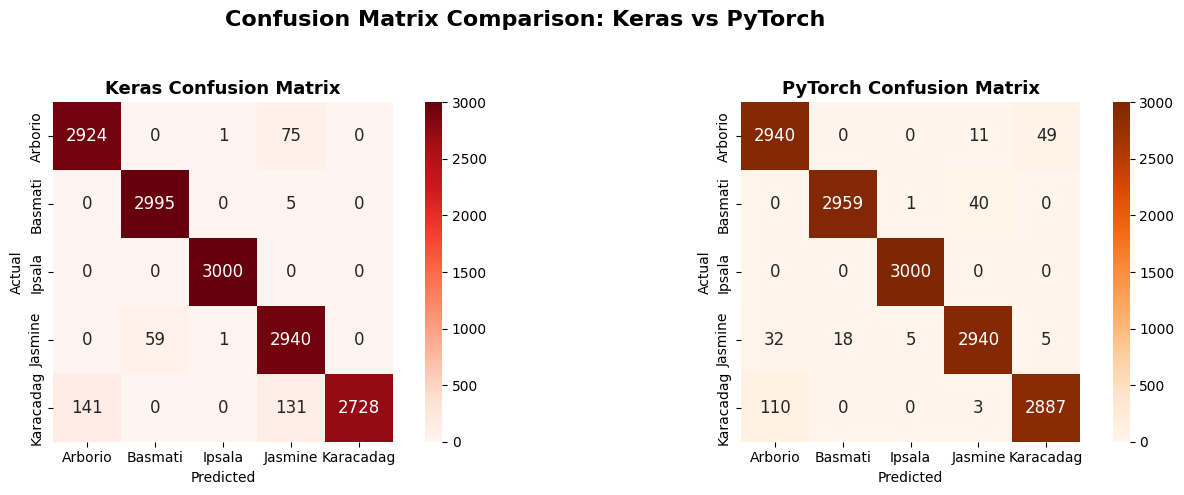

In [53]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

keras_cm = confusion_matrix(
    keras_labels,
    keras_predictions
)

torch_cm = confusion_matrix(
    torch_labels,
    torch_predictions
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

sns.heatmap(
    keras_cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=classes,
    yticklabels=classes,
    ax=axes[0],
    cbar=True,
    square=True,
    vmin=0,
    vmax=3000,
    annot_kws={"size": 12}
)

axes[0].set_title(
    "Keras Confusion Matrix",
    fontsize=13,
    fontweight="bold"
)

axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    torch_cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=classes,
    yticklabels=classes,
    ax=axes[1],
    cbar=True,
    square=True,
    vmin=0,
    vmax=3000,
    annot_kws={"size": 12}
)

axes[1].set_title(
    "PyTorch Confusion Matrix",
    fontsize=13,
    fontweight="bold"
)

axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

fig.suptitle(
    "Confusion Matrix Comparison: Keras vs PyTorch",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(
    rect=[0, 0, 1, 0.94]
)

plt.show()

## 20. Classification Reports

Accuracy alone does not fully describe multiclass classification performance.

We therefore calculate precision, recall, and F1-score for each rice variety.

This allows us to identify whether a model performs consistently across all
five classes or performs particularly well on only a subset of them.

In [54]:
print("=" * 70)
print("KERAS CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        keras_labels,
        keras_predictions,
        target_names=classes,
        digits=4
    )
)


print("\n" + "=" * 70)
print("PYTORCH CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        torch_labels,
        torch_predictions,
        target_names=classes,
        digits=4
    )
)

KERAS CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Arborio     0.9540    0.9747    0.9642      3000
     Basmati     0.9807    0.9983    0.9894      3000
      Ipsala     0.9993    1.0000    0.9997      3000
     Jasmine     0.9330    0.9800    0.9559      3000
   Karacadag     1.0000    0.9093    0.9525      3000

    accuracy                         0.9725     15000
   macro avg     0.9734    0.9725    0.9724     15000
weighted avg     0.9734    0.9725    0.9724     15000


PYTORCH CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Arborio     0.9539    0.9800    0.9668      3000
     Basmati     0.9940    0.9863    0.9901      3000
      Ipsala     0.9980    1.0000    0.9990      3000
     Jasmine     0.9820    0.9800    0.9810      3000
   Karacadag     0.9816    0.9623    0.9719      3000

    accuracy                         0.9817     15000
   macro avg     0.9819    0.9817    0.9818     15000
weighted avg     0

## 21. Framework Comparison

The final comparison summarizes the main experimental results obtained from
the two implementations.

The comparison focuses on:

- Test accuracy
- Best validation accuracy
- Test loss
- Training time
- Number of trainable parameters

Training time should be interpreted together with the hardware and software
environment used for the experiment.

In [57]:
keras_best_val_accuracy = max(
   history_keras.history["val_accuracy"]
)

torch_best_val_accuracy = max(
    torch_history["val_accuracy"]
)

keras_params = keras_model.count_params()

torch_params = sum(
    parameter.numel()
    for parameter in torch_model.parameters()
)


comparison_df = pd.DataFrame({
    "Metric": [
        "Test Accuracy",
        "Best Validation Accuracy",
        "Test Loss",
        "Training Time (seconds)",
        "Trainable Parameters"
    ],

    "TensorFlow / Keras": [
        keras_test_accuracy,
        keras_best_val_accuracy,
        keras_test_loss,
        keras_training_time,
        keras_params
    ],

    "PyTorch": [
        torch_test_accuracy,
        torch_best_val_accuracy,
        torch_test_loss,
        torch_training_time,
        torch_params
    ]
})


comparison_df

,Metric,TensorFlow / Keras,PyTorch
0,Test Accuracy,0.972467,0.981733
1,Best Validation Accuracy,0.989133,0.981067
2,Test Loss,0.084393,0.051262
3,Training Time (seconds),679.164081,1596.665318
4,Trainable Parameters,110405.000000,110405.000000


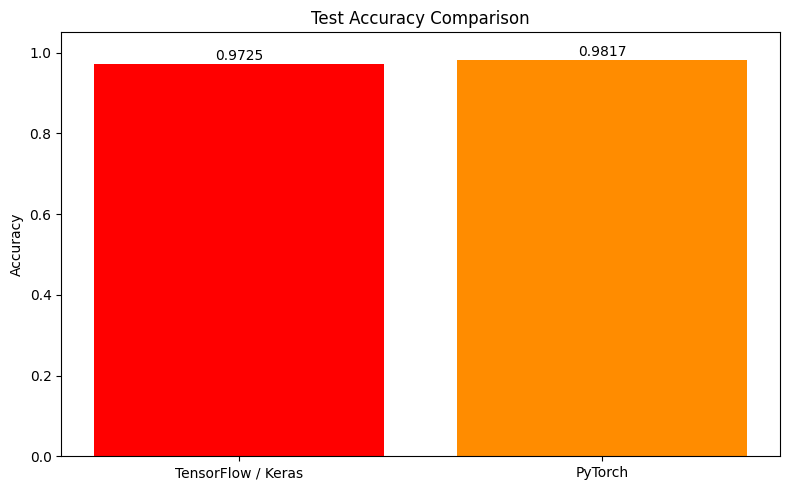

In [60]:
KERAS_COLOR = "red"
PYTORCH_COLOR = "darkorange"

frameworks = [
    "TensorFlow / Keras",
    "PyTorch"
]

accuracies = [
    keras_test_accuracy,
    torch_test_accuracy
]

colors = [KERAS_COLOR, PYTORCH_COLOR]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    frameworks,
    accuracies,
    color=colors
)

plt.title("Test Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)

for bar, value in zip(
    bars,
    accuracies
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.01,
        f"{value:.4f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

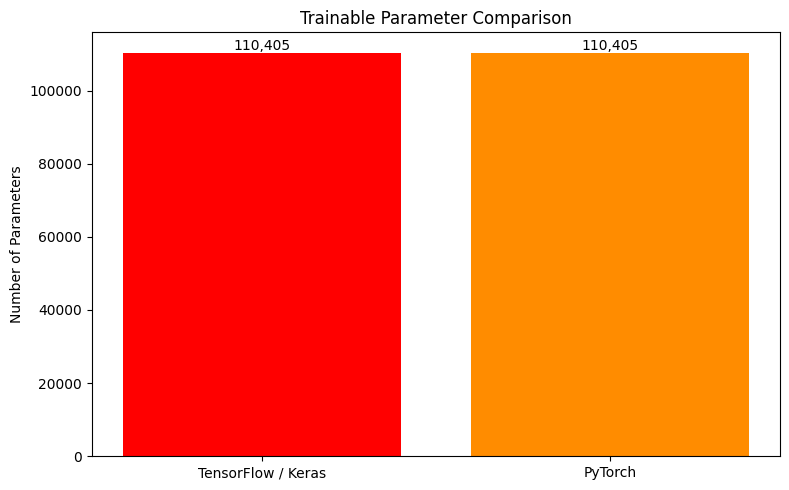

In [63]:
KERAS_COLOR = "red"
PYTORCH_COLOR = "darkorange"

parameter_counts = [
    keras_params,
    torch_params
]

colors = [KERAS_COLOR, PYTORCH_COLOR]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    frameworks,
    parameter_counts,
    color=colors
)

plt.title("Trainable Parameter Comparison")
plt.ylabel("Number of Parameters")

for bar, value in zip(
    bars,
    parameter_counts
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## 22. Saving Experimental Results

The main numerical results are saved as a CSV file.

Saving the metrics separately from the notebook makes it easier to compare
future experiments and prevents results from being lost when the notebook
runtime is reset.

In [64]:
results_dir = Path("results")

results_dir.mkdir(
    exist_ok=True
)

comparison_df.to_csv(
    results_dir / "framework_comparison.csv",
    index=False
)

print(
    f"Results saved to: "
    f"{results_dir / 'framework_comparison.csv'}"
)

Results saved to: results/framework_comparison.csv


## 23. Saving Trained Models

The trained models are saved as experiment artifacts.

The model files are intentionally excluded from the Git repository through
`.gitignore` because trained model checkpoints can become large.

For the public repository, the notebook and experiment results are more
important than storing large binary checkpoints directly in Git.

In [65]:
models_dir = Path("models")

models_dir.mkdir(
    exist_ok=True
)


# Keras
keras_model.save(
    models_dir / "rice_cnn_keras.keras"
)


# PyTorch
torch.save(
    torch_model.state_dict(),
    models_dir / "rice_cnn_pytorch.pth"
)


print("Models saved successfully.")

Models saved successfully.


# 24. Conclusion

This project implemented a lightweight CNN for five-class rice variety
classification using both TensorFlow/Keras and PyTorch.

The experiment followed a common data preparation and evaluation protocol in
order to make the framework comparison meaningful.

### What was evaluated?

- Dataset structure and class distribution
- RGB image preprocessing
- Training and validation behavior
- Test-set classification performance
- Per-class precision, recall, and F1-score
- Confusion matrices
- Training time
- Model parameter count

### Final Result

The final results should be interpreted based on the actual execution of this
notebook rather than predetermined expectations.

The best framework is therefore determined empirically from the reported
test performance and computational characteristics.

### Possible Future Improvements

Several directions could be explored in future experiments:

- Higher input resolution
- More systematic augmentation
- Batch Normalization
- Learning-rate scheduling experiments
- Transfer learning
- Larger CNN architectures
- Cross-validation
- Model deployment and inference benchmarking

---

### Reproducibility

This notebook is designed to run in Google Colab.

The dataset is downloaded automatically using KaggleHub, and the main
experimental parameters are centralized in the configuration section.

For reproducible comparisons, the same dataset split, image resolution,
class mapping, training configuration, and evaluation protocol are used for
both framework implementations.

> Note: Exact training time and floating-point results may vary depending on
> the available hardware, CUDA/cuDNN versions, TensorFlow/PyTorch versions,
> and runtime configuration.